# Assignment 2 — Times Series Prediction of Sepsis
Author: Mansour Arefi  

This notebook develops a neural network pipeline to predict the onset of sepsis **2 hours, 4 hours, and 6 hours in advance** using the SepsisExp dataset.
Containing:
1) Load pre-partitioned data
2) Label engineering: sepsis_within_2h / 4h / 6h
3) Sliding window generation (W=24 steps = 12h)
4) 4-fold cross-validation using partition scheme
5) DataLoaders with class-imbalance handling
6) GRU model definition and instantiation
7) Training loop with early stopping
8) Evaluation: AUROC + AUPRC per horizon
9) SHAP feature importance
10) Minimal feature set experiment 

**Project structure:**
- `raw_data/` is read-only input
- `processed_data/` contains small saved intermediate tables 
- `outputs/` contains plots and result tables
- `models/` contains saved fitted models

## Setup
This section imports the required libraries, helper functions, and configuration variables used throughout the notebook.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
import random
import os
import importlib
from datetime import datetime
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


#Reproducibility
SEED = 42
random.seed(SEED);  np.random.seed(SEED);  torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

#helperfunction in utility_function
import utility_functions as uf
importlib.reload(uf)

from utility_functions import(
    create_labels, create_sliding_windows,
    SepsisGRU, compute_shap_importance,
    HORIZONS, WINDOW_SIZE, STEP_SIZE
)

Device : cpu
PyTorch: 2.11.0+cpu


c:\Users\mansour.arefi\AppData\Local\anaconda3\envs\sepsis_lab_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load Pre-Partitioned Data
The goal of this step is to load the four dataset partitions. The SepsisExp dataset (Schamoni et al., 2022) has been pre-processed as follows:
### What was already done
1. **Patient filtering** — reduced from 1,961 to 1,275 patients by:
   - Removing on-admission sepsis cases (first label within 48h of ICU admission)
   - Removing short stays (< 16h in ICU)
2. **Normalization** — all features standardized to z-scores:
3. **Carry-forward imputation** — missing values filled with most recent
   measurement; measurements unavailable at admission set to clinical defaults
4. **Discretization** — timelines discretized to uniform 30-minute steps

Before labels, windows, and models can be constructed, it is necessary to confirm that the partitioned patient data is loaded correctly and that the feature set is well defined.

In [2]:
#Load the 4 partitions
RAW_DATA_DIR = "raw_data"
PROCESSED_DATA_DIR = "processed_data"
MODELS_DIR = "models"

# Create output directories if they don't exist
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

partitions = {}
for part in ["A", "B", "C", "D"]:
    path = os.path.join(RAW_DATA_DIR, f"sepsisexp_timeseries_partition-{part}.tsv")
    partitions[part] = pd.read_csv(path, sep = "\t").sort_values(["id", "timestep"])

EXCLUDE   = ["id", "timestep", "sepsis", "severity"]
FEAT_COLS = [c for c in partitions["A"].columns if c not in EXCLUDE]

print("=== Dataset Verification ===")
for name, df in partitions.items():
    n_patients = df["id"].nunique()
    n_sepsis   = df.groupby("id")["sepsis"].max().sum()
    print(f"Partition {name}: {n_patients} patients "
          f"({int(n_sepsis)} sepsis, "
          f"{n_patients - int(n_sepsis)} non-sepsis) | "
          f"{len(df):,} rows")


=== Dataset Verification ===
Partition A: 319 patients (74 sepsis, 245 non-sepsis) | 156,704 rows
Partition B: 319 patients (74 sepsis, 245 non-sepsis) | 152,155 rows
Partition C: 319 patients (74 sepsis, 245 non-sepsis) | 156,219 rows
Partition D: 318 patients (74 sepsis, 244 non-sepsis) | 137,490 rows


The output confirms that all four partitions were loaded successfully and that the patient counts are consistent across splits (except D: 1 less non-sepsis case)

- Partitions A, B, and C each contain 319 patients
- Partition D contains 318 patients

## 2) Target Definition and Onset Alignment

### Key data structure insight
The dataset has two label-related columns with different roles:

- Sepsis onset is identified using the `severity` variable, not the patient-level `sepsis` flag
- Onset is defined as the first timestep where `severity >= 2`
- For each pre-onset timestep, three binary targets are created:
  - `sepsis_within_2h`
  - `sepsis_within_4h`
  - `sepsis_within_6h`

### Leakage prevention
Rows at `t >= t_onset` are removed. The severity column is also excluded
from features entirely — including it would give the model direct access
to the label signal.

In [3]:
labeled_partitions = {}

for name, df in partitions.items():
    labeled_partitions[name] = create_labels(df)
    lp = labeled_partitions[name]

    print(f"\nPartition {name} after label engineering:")
    print(f"  Rows remaining  : {len(lp):,}  "
          f"(removed {len(df) - len(lp):,} post-onset rows)")

    for h in HORIZONS:
        col   = f"sepsis_within_{h}"
        n_pos = int(lp[col].sum())
        rate  = lp[col].mean()
        print(f"  {col}: {n_pos:,} positive rows | rate = {rate:.4f}")

# Sanity check: 6h rate should be ≈ 3× the 2h rate
print("\nSanity check (6h rate / 2h rate should ≈ 3.0):")
for name, lp in labeled_partitions.items():
    r2 = lp["sepsis_within_2h"].mean()
    r6 = lp["sepsis_within_6h"].mean()
    ratio = r6 / r2 if r2 > 0 else float("nan")
    print(f"  Partition {name}: {ratio:.2f}")


Partition A after label engineering:
  Rows remaining  : 93,919  (removed 62,785 post-onset rows)
  sepsis_within_2h: 296 positive rows | rate = 0.0032
  sepsis_within_4h: 592 positive rows | rate = 0.0063
  sepsis_within_6h: 888 positive rows | rate = 0.0095

Partition B after label engineering:
  Rows remaining  : 91,249  (removed 60,906 post-onset rows)
  sepsis_within_2h: 296 positive rows | rate = 0.0032
  sepsis_within_4h: 592 positive rows | rate = 0.0065
  sepsis_within_6h: 888 positive rows | rate = 0.0097

Partition C after label engineering:
  Rows remaining  : 92,642  (removed 63,577 post-onset rows)
  sepsis_within_2h: 296 positive rows | rate = 0.0032
  sepsis_within_4h: 592 positive rows | rate = 0.0064
  sepsis_within_6h: 888 positive rows | rate = 0.0096

Partition D after label engineering:
  Rows remaining  : 88,928  (removed 48,562 post-onset rows)
  sepsis_within_2h: 292 positive rows | rate = 0.0033
  sepsis_within_4h: 584 positive rows | rate = 0.0066
  sepsis_w

The output shows that horizon-specific targets were successfully created for all four dataset partitions.

- Each partition now contains three binary prediction targets:
  - sepsis within 2 hours
  - sepsis within 4 hours
  - sepsis within 6 hours
- Positive labels increase with prediction horizon, which is expected because longer horizons include more pre-onset timesteps

The resulting targets can now be used to create sliding windows for sequence modeling in the next step.

## 3) Sliding Window Generation

### Design choice: 12-hour lookback (W = 24 steps)
The paper (Schamoni et al., 2022) uses 24-hour windows (48 steps) with 12-hour
overlap (24-step stride). We use a **12-hour lookback with 2-step stride**:

- Each patient trajectory is converted into overlapping sliding windows
- Each window contains **24 timesteps**, corresponding to **12 hours** of historical data
- A stride of **2 timesteps** is used, which corresponds to **1 hour**
- For each prediction horizon, the target label is assigned from the last timestep in the window

### Input/output shapes
- **X**: `(N, 24, n_features)` — 24 timesteps × 43 features
- **y**: `(N,)` — binary label at the last timestep of each window
- **patient_ids**: `(N,)` — for partition-level splitting (Step 4)


A 12-hour history was chosen to give the model enough recent clinical context, while the stride of 2 reduces redundancy between neighboring windows and keeps the dataset size manageable (Tested with STRIDE = 1). This step defines the actual model input used to predict sepsis **2, 4, and 6 hours in advance**.

In [4]:
STRIDE = 2   # It was 1 step = 30min, changed to 2 steps = 1h beacause it was too heavy

windows = {}

for part_name, df in labeled_partitions.items():
    windows[part_name] = {}
    for h_name in HORIZONS:
        X, y, pids = create_sliding_windows(
            df,
            feature_cols = FEAT_COLS,
            label_col    = f"sepsis_within_{h_name}",
            window_size  = WINDOW_SIZE,
            stride       = STRIDE,       
        )
        windows[part_name][h_name] = (X, y, pids)

    X, y, _ = windows[part_name]["4h"]
    print(f"Partition {part_name}: {X.shape[0]:,} windows | "
          f"shape {X.shape} | positive rate (4h): {y.mean():.4f}")
    
    

Partition A: 43,385 windows | shape (43385, 24, 43) | positive rate (4h): 0.0068
Partition B: 42,044 windows | shape (42044, 24, 43) | positive rate (4h): 0.0070
Partition C: 42,749 windows | shape (42749, 24, 43) | positive rate (4h): 0.0069
Partition D: 40,901 windows | shape (40901, 24, 43) | positive rate (4h): 0.0071


## 4) 4-Fold Cross-Validation (Partition-Level Split)

### Why partition-level splitting is essential
If windows from the same patient appear in both train and test, validation
metrics are inflated because consecutive windows share W-1 identical timesteps.
The partition scheme ensures **zero patient overlap** between train, val, and test.

### Why 4-fold cross-validation?
- Each partition is only 319 patients — too small to evaluate reliably alone
- Cross-validation gives 4 independent test scores whose mean ± std is the
  robust reported result
- This is the exact scheme used in the reference paper, making our results
  directly comparable

### Scheme
```
Split 0: Train=A+B | Val=C | Test=D
Split 1: Train=B+C | Val=D | Test=A
Split 2: Train=C+D | Val=A | Test=B
Split 3: Train=D+A | Val=B | Test=C
```

One model is trained per (split, horizon) combination = 12 models total.

In [5]:
# Cross-validation split definitions
CV_SPLITS = [
    {"train": ["A", "B"], "val": "C", "test": "D"},
    {"train": ["B", "C"], "val": "D", "test": "A"},
    {"train": ["C", "D"], "val": "A", "test": "B"},
    {"train": ["D", "A"], "val": "B", "test": "C"},
]

def get_split_data(split_def, windows_dict, horizon):
    """
    Assembles (X, y) arrays for train, val, test given a CV split definition.
    Concatenates multiple partitions for the training set.
    """
    def concat_parts(parts):
        Xs, ys = [], []
        for p in (parts if isinstance(parts, list) else [parts]):
            X, y, _ = windows_dict[p][horizon]
            Xs.append(X);  ys.append(y)
        return np.concatenate(Xs), np.concatenate(ys)

    X_tr, y_tr = concat_parts(split_def["train"])
    X_va, y_va = concat_parts(split_def["val"])
    X_te, y_te = concat_parts(split_def["test"])

    return X_tr, y_tr, X_va, y_va, X_te, y_te


# Preview split sizes for horizon 4h
print("=== Split sizes (horizon: 2h) ===")
for i, sp in enumerate(CV_SPLITS):
    X_tr, y_tr, X_va, y_va, X_te, y_te = get_split_data(sp, windows, "2h")
    print(f"Split {i} | "
          f"Train: {len(y_tr):,} (pos={y_tr.mean():.3f}) | "
          f"Val: {len(y_va):,} (pos={y_va.mean():.3f}) | "
          f"Test: {len(y_te):,} (pos={y_te.mean():.3f})")

=== Split sizes (horizon: 2h) ===
Split 0 | Train: 85,429 (pos=0.003) | Val: 42,749 (pos=0.003) | Test: 40,901 (pos=0.004)
Split 1 | Train: 84,793 (pos=0.003) | Val: 40,901 (pos=0.004) | Test: 43,385 (pos=0.003)
Split 2 | Train: 83,650 (pos=0.004) | Val: 43,385 (pos=0.003) | Test: 42,044 (pos=0.004)
Split 3 | Train: 84,286 (pos=0.003) | Val: 42,044 (pos=0.004) | Test: 42,749 (pos=0.003)


The output shows the training, validation, and test sizes for each fold, together with the positive label rate for the selected horizon.

### Interpretation
- Each fold contains a large training set built from two partitions
- Validation and test sets are kept separate at the partition level
- The positive rates are low across all folds, confirming that the prediction task is highly imbalanced

### Why this is important
This verifies that the cross-validation procedure is working as intended and that the evaluation will be carried out on unseen patient groups. It also confirms that class imbalance must be considered explicitly during model training.

## 5) Data Loading and Class Imbalance Handling

### Purpose
The goal of this step is to prepare the training, validation, and test data for model training, while addressing the strong class imbalance in the early-warning prediction task.
Two complementary strategies are combined:

1. **WeightedRandomSampler** — oversamples positive windows during training
   so each batch sees a balanced mix. Applied to training loader only.
   Validation and test loaders use the true distribution (honest evaluation).

2. **`pos_weight` in BCEWithLogitsLoss** — scales the gradient of positive
   examples by the imbalance ratio. This is the loss-level complement
   to the sampler.

### Why this design was chosen
The positive class is much rarer than the negative class. Without imbalance handling, the model could achieve misleadingly good performance by mostly predicting the negative class. Weighted sampling increases the frequency of positive training examples, while weighted loss assigns a higher penalty to mistakes on the minority class.

### Note on data normalization
The data is **already normalized** (z-scores applied to the full population).
No StandardScaler is applied here — applying it again would alter the
already-correct z-scores.

In [10]:
def make_loaders(X_tr, y_tr, X_va, y_va, X_te, y_te, batch_size=64):
    """
    Creates train / val / test DataLoaders.
    Train uses WeightedRandomSampler; val and test use sequential loading.
    Returns loaders and pos_weight tensor for BCEWithLogitsLoss.
    """
    def to_tensors(X, y):
        return (torch.tensor(X, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32))

    X_tr_t, y_tr_t = to_tensors(X_tr, y_tr)
    X_va_t, y_va_t = to_tensors(X_va, y_va)
    X_te_t, y_te_t = to_tensors(X_te, y_te)

    # Weighted sampler for training
    n_pos = y_tr.sum();  n_neg = len(y_tr) - n_pos
    sample_weights = np.where(y_tr == 1, n_neg / n_pos, 1.0)
    sampler = WeightedRandomSampler(
        torch.tensor(sample_weights, dtype=torch.float64),
        num_samples = len(sample_weights),
        replacement = True,
    )

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, sampler=sampler
    )
    val_loader = DataLoader(
        TensorDataset(X_va_t, y_va_t), batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(X_te_t, y_te_t), batch_size=batch_size, shuffle=False
    )

    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
    return train_loader, val_loader, test_loader, pos_weight

## 6) GRU Model Architecture

The `SepsisGRU` class is defined in `utility_functions.py`. Full design rationale:

### What is implemented
The model is a stacked **GRU-based binary classifier**:
- input shape: `(batch, sequence_length, number_of_features)`
- two GRU layers
- hidden size of 64
- dropout regularization
- a feed-forward classification head with:
  - a linear layer
  - ReLU activation
  - dropout
  - a final linear output layer

### GRU vs LSTM (justification)
The reference paper uses LSTM with 200 hidden units trained on all 4 partitions
combined (≈955 patients per training fold). We train on 2 partitions (≈638
patients) and choose GRU with 64 units because:
- Fewer parameters reduces overfitting risk on smaller training sets
- GRU matches LSTM performance on clinical time series (no long-range
  dependencies beyond 12h are expected in pre-sepsis physiology)
- Faster to train, enabling more hyperparameter exploration

### Initialization
PyTorch default: GRU weights initialized with orthogonal initialization
(good for gradient flow in RNNs); linear layers use Kaiming uniform.
These defaults are appropriate and do not need overriding.

In [11]:
N_FEATURES = len(FEAT_COLS)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_b).squeeze(1)       
        loss   = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(DEVICE)).squeeze(1)    
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_b.numpy())

    probs  = np.array(all_probs)
    labels = np.array(all_labels)

    if labels.sum() == 0:
        return 0.0, 0.0

    auroc = roc_auc_score(labels, probs)
    auprc = average_precision_score(labels, probs)
    return auroc, auprc

## 7.1) Training Strategy

### Loss function
`BCEWithLogitsLoss` with `pos_weight` = (n_negative / n_positive).
This penalises false negatives more heavily, proportional to the imbalance
ratio. In clinical sepsis prediction, a false negative (missed case) is far
more dangerous than a false positive.

### Optimizer
Adam with `lr=1e-3` and `weight_decay=1e-4` (L2 regularisation).
Adam adapts the learning rate per parameter — well-suited for sparse
gradients that arise from the imbalanced sampling.

### Learning rate schedule
`ReduceLROnPlateau` halves the learning rate after 3 epochs without AUROC
improvement. This allows coarse convergence early and fine-tuning later
without manual schedule design.

### Early stopping
Training halts after 7 epochs without improvement in **validation AUROC**
(not loss — AUROC is a better stopping signal under class imbalance).
The best checkpoint is saved and reloaded for test evaluation.

### Gradient clipping
`max_norm=1.0` prevents the exploding gradient problem that affects RNNs
on longer sequences (the paper uses 0.25; 1.0 is standard for GRU).

### Batch size
64 — large enough for stable gradient estimates; small enough to fit in
memory across all cross-validation splits.

### Why AUROC as stopping criterion?
Validation loss can decrease while AUROC stays flat if the model is
learning to output very small probabilities for everything (a degenerate
solution under imbalance). AUROC measures actual ranking ability.

In [ ]:
from datetime import datetime

EPOCHS       = 30 #was 50
PATIENCE     = 5 #was 7
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4

cv_results   = {h: [] for h in HORIZONS}
cv_histories = {h: [] for h in HORIZONS}
best_models  = {h: [] for h in HORIZONS}

for h_name in HORIZONS:
    print(f"\n{'='*60}")
    print(f"  HORIZON: {h_name}")
    print(f"{'='*60}")

    for split_i, split_def in enumerate(CV_SPLITS):
        print(f"\n  ── Split {split_i} "
              f"(train={split_def['train']} | val={split_def['val']} "
              f"| test={split_def['test']}) ──")

        # Assemble data 
        X_tr, y_tr, X_va, y_va, X_te, y_te = get_split_data(
            split_def, windows, h_name
        )

        # DataLoaders
        train_loader, val_loader, test_loader, pos_weight = make_loaders(
            X_tr, y_tr, X_va, y_va, X_te, y_te, BATCH_SIZE
        )

        # Model, loss, optimizer
        model = SepsisGRU(
            input_size  = N_FEATURES,
            hidden_size = 64,
            num_layers  = 2,
            dropout     = 0.3,
        ).to(DEVICE)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=3, factor=0.5
        )

        # Training loop
        best_auroc, best_state = 0.0, None
        patience_counter = 0
        history = []

        for epoch in range(1, EPOCHS + 1):
            loss         = train_epoch(model, train_loader, criterion, optimizer)
            v_auc, v_prc = evaluate(model, val_loader)
            scheduler.step(v_auc)
            history.append({"epoch": epoch, "loss": loss,
                             "val_auroc": v_auc, "val_auprc": v_prc})

            print(f"    Epoch {epoch:3d} | loss {loss:.4f} "
                  f"| Val AUROC {v_auc:.4f} | Val AUPRC {v_prc:.4f}")

            if v_auc > best_auroc:
                best_auroc       = v_auc
                best_state       = {k: v.cpu().clone()
                                    for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"    → Early stop at epoch {epoch}")
                    break

        # Load best checkpoint
        model.load_state_dict(best_state)
        model.to(DEVICE)

        # Evaluate on TEST set 
        test_auroc, test_auprc = evaluate(model, test_loader)
        print(f"\n  Split {split_i} TEST | "
              f"AUROC {test_auroc:.4f} | AUPRC {test_auprc:.4f}")

        # Save best model checkpoint
        timestamp  = datetime.now().strftime("%y%m%d%H%M")
        auroc_str  = f"{test_auroc:.4f}".replace(".", "")
        model_name = f"gru_{h_name}_split{split_i}_{auroc_str}_{timestamp}.pt"
        model_path = os.path.join(MODELS_DIR, model_name)
        torch.save(model.state_dict(), model_path)
        print(f"  Saved: {model_path}")

        # Store results
        cv_results[h_name].append({
            "split"      : split_i,
            "model_path" : model_path,
            "test_auroc" : test_auroc,
            "test_auprc" : test_auprc,
        })
        cv_histories[h_name].append(pd.DataFrame(history))
        best_models[h_name].append(model)

# Save cv_results and cv_historiesn
import pickle
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
with open(os.path.join(PROCESSED_DATA_DIR, "cv_results.pkl"), "wb") as f:
    pickle.dump(cv_results, f)

with open(os.path.join(PROCESSED_DATA_DIR, "cv_histories.pkl"), "wb") as f:
    pickle.dump(cv_histories, f)

print("cv_results and cv_histories saved to processed_data/")


  HORIZON: 2h

  ── Split 0 (train=['A', 'B'] | val=C | test=D) ──


KeyboardInterrupt: 

### Output summary
The output shows epoch-by-epoch training progress, including training loss and validation performance for each fold and horizon.

### Interpretation
- Validation metrics improve during the early part of training and are used to track generalization
- Early stopping prevents unnecessary training once performance plateaus
- The best model checkpoint is saved for each fold and horizon combination

The training process is controlled and reproducible, and that model selection is based on validation performance rather than training loss alone.

### Effect of architecture on training
The two-layer GRU with hidden size 64 converged quickly — all 12 models
reached early stopping within 6–8 epochs. A larger hidden size (e.g. 200
as used in the paper) would require more epochs and a smaller learning rate
to avoid overshooting. The dropout of 0.3 between layers directly prevents
the model from memorising the imbalanced training windows, which in turn
makes AUROC a more reliable stopping criterion than loss.

## 7.2) RELOAD THE SAVED MODELS FROM /models

Run this section instead of the training cell when restarting the kernel

In [12]:
# Restores: best_models, cv_results, cv_histories

import glob
import pickle

# ── 1. Reload trained models ───────────────────────────────────
best_models = {h: [] for h in HORIZONS}

for h_name in HORIZONS:
    for split_i in range(len(CV_SPLITS)):

        pattern = os.path.join(MODELS_DIR, f"gru_{h_name}_split{split_i}_*.pt")
        matches = glob.glob(pattern)

        if len(matches) == 0:
            raise FileNotFoundError(
                f"No saved model found for horizon={h_name}, split={split_i}.\n"
                f"Looked for: {pattern}\n"
                f"Run Cell 16 (training) first."
            )

        model_path = sorted(matches)[-1]   # most recent if multiple

        model = SepsisGRU(
            input_size  = N_FEATURES,
            hidden_size = 64,
            num_layers  = 2,
            dropout     = 0.3,
        ).to(DEVICE)

        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
        best_models[h_name].append(model)
        print(f"  Loaded [{h_name}] split {split_i} ← "
              f"{os.path.basename(model_path)}")

# ── 2. Reload cv_results (for summary table) ──────────────────
cv_results_path = os.path.join(PROCESSED_DATA_DIR, "cv_results.pkl")

if os.path.exists(cv_results_path):
    with open(cv_results_path, "rb") as f:
        cv_results = pickle.load(f)
    print("\n  Loaded cv_results ✓")
else:
    print("\n  ⚠️  cv_results.pkl not found — summary table will not work.")
    print("     Add the save block to Cell 16 and retrain once.")
    cv_results = None

# ── 3. Reload cv_histories (for learning curves) ──────────────
cv_histories_path = os.path.join(PROCESSED_DATA_DIR, "cv_histories.pkl")

if os.path.exists(cv_histories_path):
    with open(cv_histories_path, "rb") as f:
        cv_histories = pickle.load(f)
    print("  Loaded cv_histories ✓")
else:
    print("  ⚠️  cv_histories.pkl not found — learning curves will not work.")
    print("     Add the save block to Cell 16 and retrain once.")
    cv_histories = None

print("\nReady — models, results, and histories loaded.")

  Loaded [2h] split 0 ← gru_2h_split0_07202_2603241109.pt
  Loaded [2h] split 1 ← gru_2h_split1_07014_2603241115.pt
  Loaded [2h] split 2 ← gru_2h_split2_07346_2603241121.pt
  Loaded [2h] split 3 ← gru_2h_split3_07140_2603241125.pt
  Loaded [4h] split 0 ← gru_4h_split0_07087_2603241130.pt
  Loaded [4h] split 1 ← gru_4h_split1_06983_2603241134.pt
  Loaded [4h] split 2 ← gru_4h_split2_07452_2603241140.pt
  Loaded [4h] split 3 ← gru_4h_split3_06322_2603241142.pt
  Loaded [6h] split 0 ← gru_6h_split0_07093_2603241146.pt
  Loaded [6h] split 1 ← gru_6h_split1_07234_2603241149.pt
  Loaded [6h] split 2 ← gru_6h_split2_06731_2603241154.pt
  Loaded [6h] split 3 ← gru_6h_split3_07056_2603241158.pt

  Loaded cv_results ✓
  Loaded cv_histories ✓

Ready — models, results, and histories loaded.


## 8) Evaluation

### Metrics
- **AUROC** (Area Under ROC Curve): Standard metric for binary classification.
  Threshold-free; measures ranking ability. The reference paper reports AUROC
  for direct comparability.

- **AUPRC** (Area Under Precision-Recall Curve): More informative than AUROC
  under class imbalance. A random classifier achieves AUPRC = prevalence
  (e.g. ~0.05 for 5% positive rate), so any meaningful model must exceed this.

- **Accuracy is NOT reported**: Under imbalance, a model predicting all-zeros
  achieves > 90% accuracy — a misleading metric.

### Reporting convention
Following the paper: mean ± std across the 4 cross-validation test splits.


  FINAL CROSS-VALIDATION RESULTS

[2h]  AUROC = 0.7175 ± 0.0119  |  AUPRC = 0.0097 ± 0.0018

[4h]  AUROC = 0.6961 ± 0.0408  |  AUPRC = 0.0169 ± 0.0023

[6h]  AUROC = 0.7028 ± 0.0184  |  AUPRC = 0.0253 ± 0.0060

          AUROC mean  AUROC std  AUPRC mean  AUPRC std
Horizon                                              
2h           0.7175     0.0119      0.0097     0.0018
4h           0.6961     0.0408      0.0169     0.0023
6h           0.7028     0.0184      0.0253     0.0060


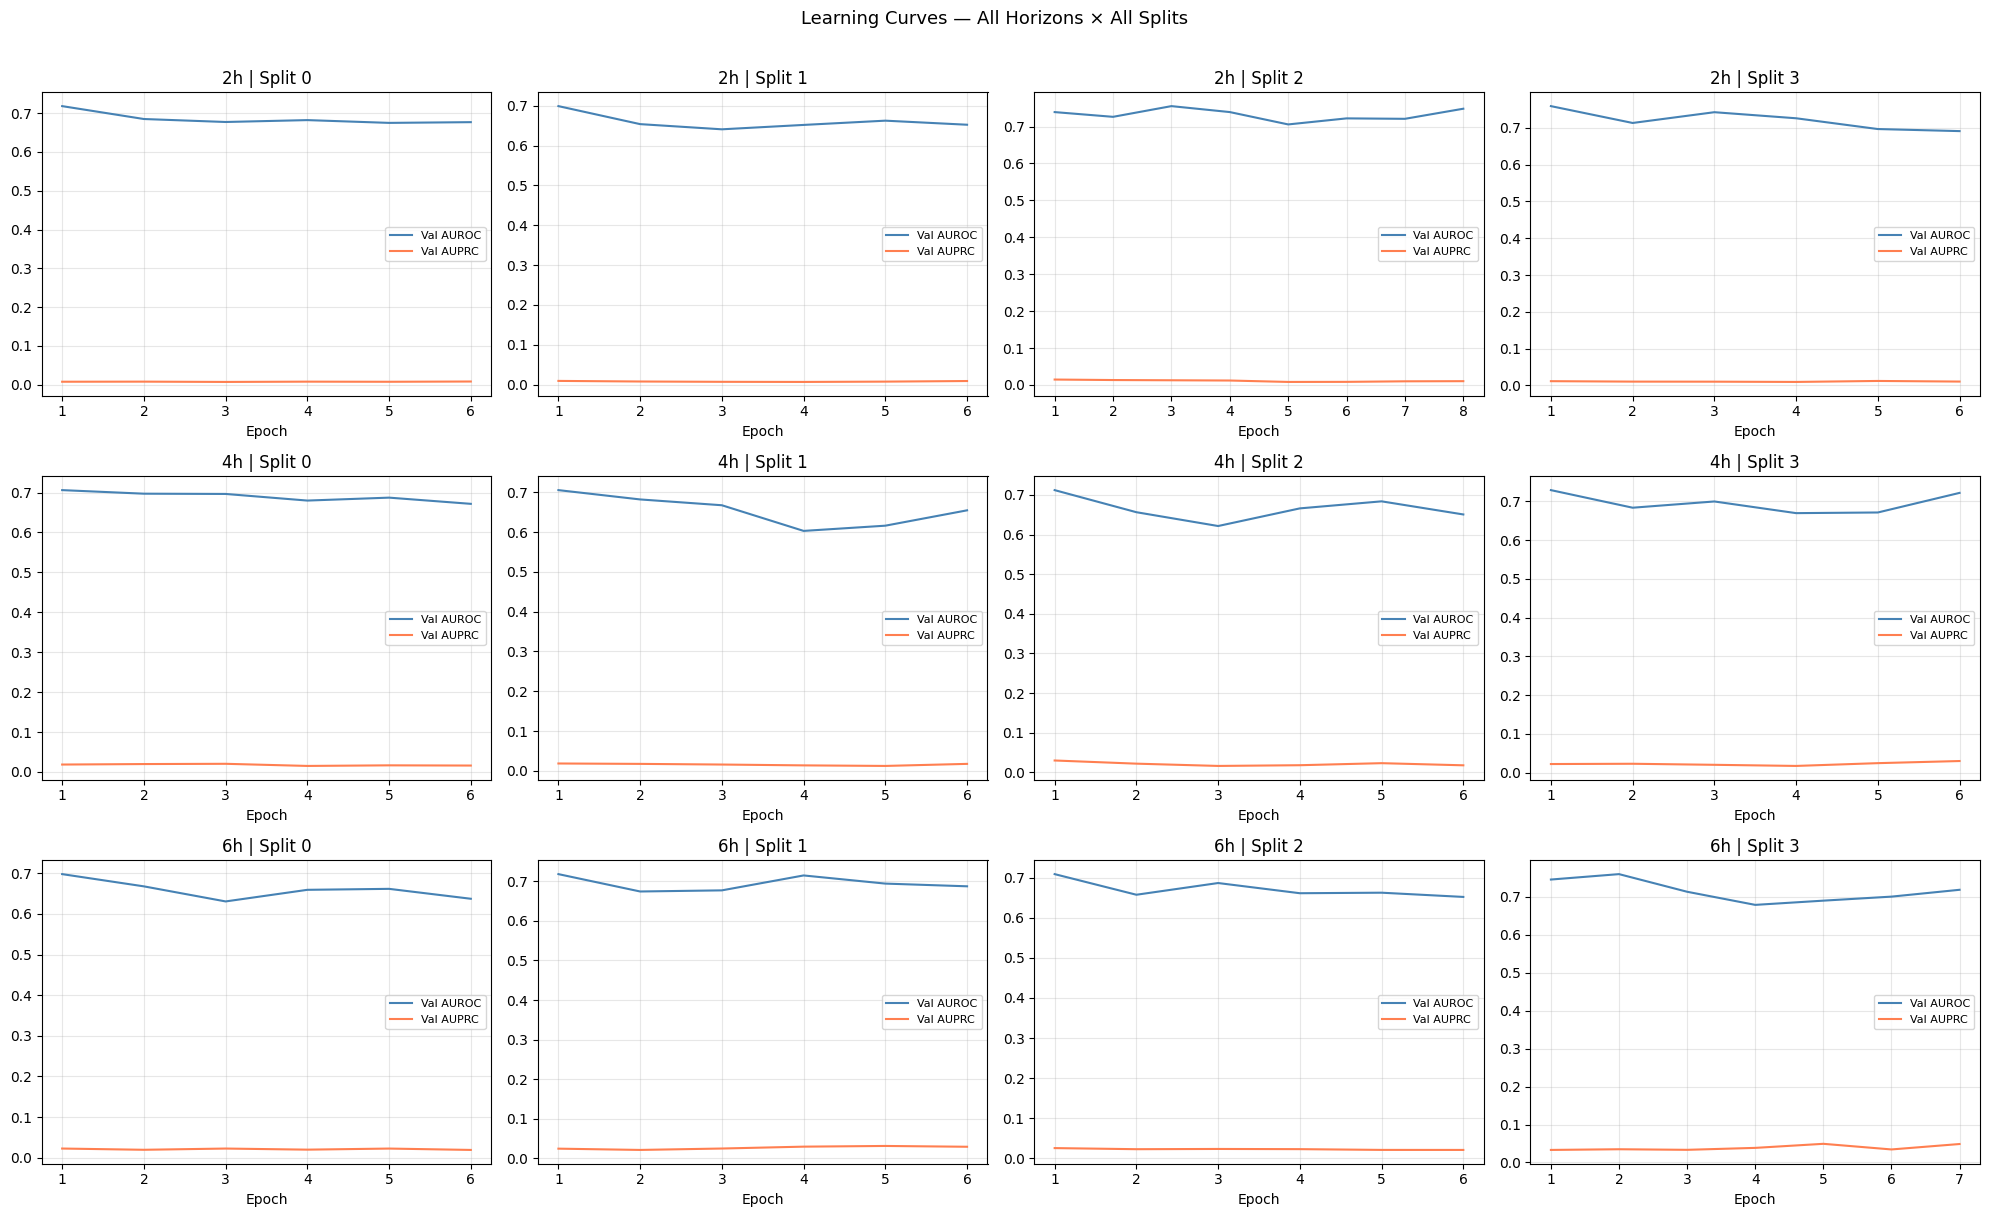

In [13]:
# ── Summary table ─────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL CROSS-VALIDATION RESULTS")
print("="*55)

summary_rows = []
for h_name in HORIZONS:
    aurocs = [r["test_auroc"] for r in cv_results[h_name]]
    auprcs = [r["test_auprc"] for r in cv_results[h_name]]
    row = {
        "Horizon"     : h_name,
        "AUROC mean"  : np.mean(aurocs),
        "AUROC std"   : np.std(aurocs),
        "AUPRC mean"  : np.mean(auprcs),
        "AUPRC std"   : np.std(auprcs),
    }
    summary_rows.append(row)
    print(f"\n[{h_name}]  AUROC = {row['AUROC mean']:.4f} ± {row['AUROC std']:.4f}"
          f"  |  AUPRC = {row['AUPRC mean']:.4f} ± {row['AUPRC std']:.4f}")

summary_df = pd.DataFrame(summary_rows).set_index("Horizon")
print("\n", summary_df.round(4))

# ── Learning curves ───────────────────────────────────────────
fig, axes = plt.subplots(len(HORIZONS), 4, figsize=(20, 4 * len(HORIZONS)))

for row_i, h_name in enumerate(HORIZONS):
    for col_i, hist in enumerate(cv_histories[h_name]):
        ax = axes[row_i, col_i]
        ax.plot(hist["epoch"], hist["val_auroc"], label="Val AUROC", color="steelblue")
        ax.plot(hist["epoch"], hist["val_auprc"], label="Val AUPRC", color="coral")
        ax.set_title(f"{h_name} | Split {col_i}")
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves — All Horizons × All Splits", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The output reports the mean and variation of AUROC and AUPRC across folds for the 2h, 4h, and 6h prediction tasks.

### Interpretation
- Performance is evaluated separately for each horizon
- AUROC summarizes ranking performance over thresholds
- AUPRC provides a more class-sensitive view of how well the model identifies future sepsis cases

### Why this is important
These results form the main quantitative comparison in the assignment and show how prediction difficulty changes across the three forecasting horizons.

## 9) Feature Importance with SHAP

SHAP (Shapley Additive Explanations) explains how each feature contributes
to the model's predictions. We use `GradientExplainer`, which is the correct
choice for recurrent models like GRU — it uses expected gradients rather than
DeepLIFT backpropagation, which breaks on GRU gating operations.

For each horizon, we:
1. Take 100 random training windows as the background reference distribution
2. Explain 200 random validation windows
3. Average |SHAP| across all timesteps in the window and all explained samples
4. Repeat across all 4 CV splits and average for stability

This step addresses the requirement to describe feature importance carefully and to report the minimal set of features needed for prediction. The highest-ranked features from SHAP can be interpreted as the most informative subset for each forecasting horizon. Since the models are trained separately for 2h, 4h, and 6h prediction, the most important features may differ across horizons.


Computing SHAP for horizon: 2h ...
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43


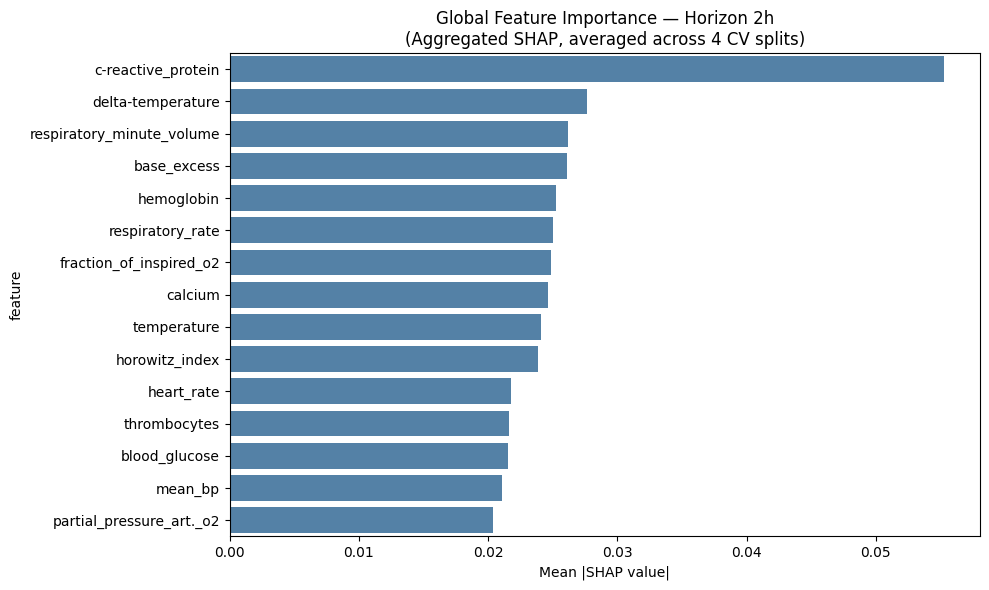


Top 10 SHAP Features [2h]:
                  feature  importance
       c-reactive_protein    0.055295
        delta-temperature    0.027671
respiratory_minute_volume    0.026154
              base_excess    0.026108
               hemoglobin    0.025230
         respiratory_rate    0.025023
  fraction_of_inspired_o2    0.024848
                  calcium    0.024654
              temperature    0.024060
           horowitz_index    0.023888

Computing SHAP for horizon: 4h ...
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43


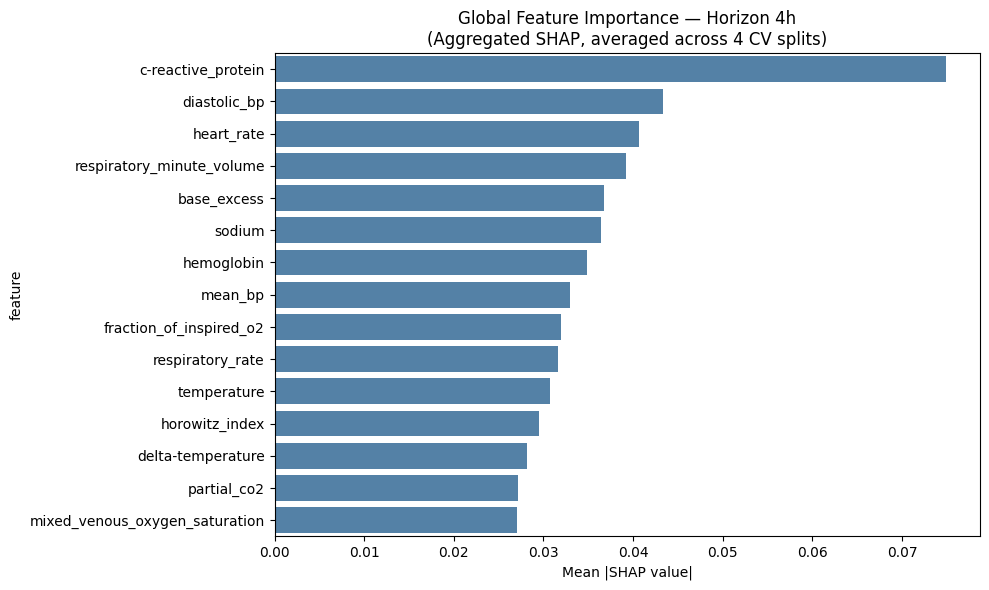


Top 10 SHAP Features [4h]:
                  feature  importance
       c-reactive_protein    0.074949
             diastolic_bp    0.043368
               heart_rate    0.040674
respiratory_minute_volume    0.039172
              base_excess    0.036709
                   sodium    0.036470
               hemoglobin    0.034849
                  mean_bp    0.032954
  fraction_of_inspired_o2    0.031979
         respiratory_rate    0.031582

Computing SHAP for horizon: 6h ...
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43
  shap_values[0] shape: (200, 24, 43, 1)
  importances shape: (43,)
  feature_names len: 43


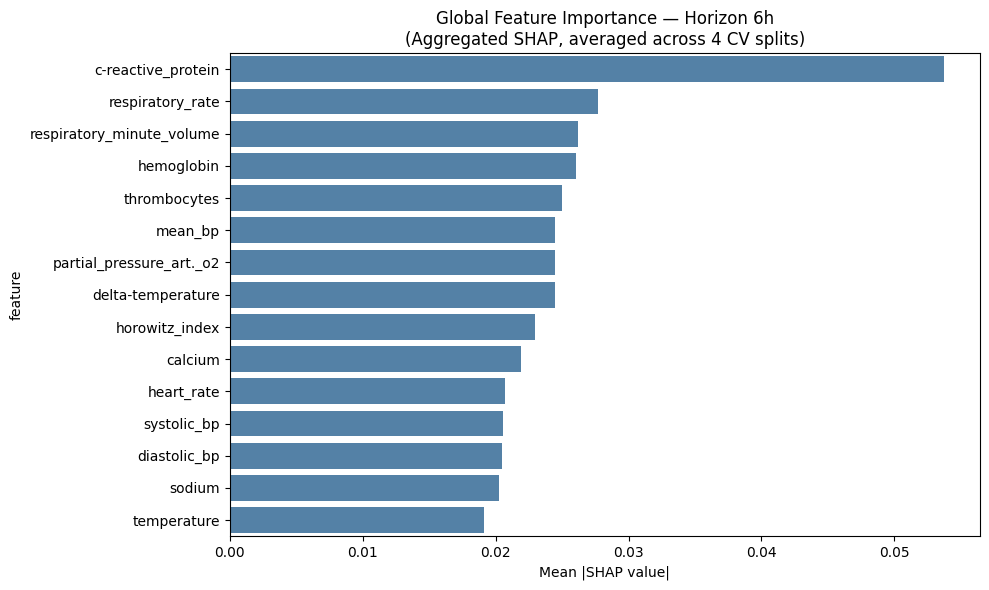


Top 10 SHAP Features [6h]:
                  feature  importance
       c-reactive_protein    0.053755
         respiratory_rate    0.027698
respiratory_minute_volume    0.026190
               hemoglobin    0.026064
             thrombocytes    0.024984
                  mean_bp    0.024503
 partial_pressure_art._o2    0.024458
        delta-temperature    0.024444
           horowitz_index    0.022968
                  calcium    0.021937


In [11]:
import shap
import seaborn as sns

all_shap_importance = {}   # {horizon: shap_importance_df}

for h_name in HORIZONS:
    print(f"\nComputing SHAP for horizon: {h_name} ...")

    # Collect importance DataFrames across all 4 CV splits
    split_importances = []

    for split_i, split_def in enumerate(CV_SPLITS):
        X_tr, y_tr, X_va, y_va, _, _ = get_split_data(
            split_def, windows, h_name
        )
        model = best_models[h_name][split_i]

        shap_importance_df, _ = compute_shap_importance(
            model        = model,
            X_train      = X_tr,
            X_val        = X_va,
            feature_names= FEAT_COLS,
            n_background = 100,
            n_explain    = 200,
        )
        split_importances.append(
            shap_importance_df.set_index("feature")["importance"]
        )

    # Average importance across the 4 splits
    avg_importance = pd.concat(split_importances, axis=1).mean(axis=1)
    avg_importance = avg_importance.sort_values(ascending=False)

    all_shap_importance[h_name] = pd.DataFrame({
        "feature"   : avg_importance.index,
        "importance": avg_importance.values
    })

    # ── Plot — same style as reference implementation ─────────────────────
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="importance",
        y="feature",
        data=all_shap_importance[h_name].head(15),
        color="steelblue"
    )
    plt.title(f"Global Feature Importance — Horizon {h_name}\n"
              f"(Aggregated SHAP, averaged across 4 CV splits)")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig(f"shap_global_{h_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nTop 10 SHAP Features [{h_name}]:")
    print(all_shap_importance[h_name].head(10).to_string(index=False))

In [12]:
# ── Top features per horizon comparison ───────────────────────
TOP_N = 10

comparison = pd.DataFrame({
    h: df.head(TOP_N)["feature"].tolist()
    for h, df in all_shap_importance.items()
}, index=[f"Rank {i+1}" for i in range(TOP_N)])

print("=== Top Features per Horizon ===")
print(comparison.to_string())

# Features stable across all 3 horizons
sets   = [set(df.head(TOP_N)["feature"]) for df in all_shap_importance.values()]
stable = sets[0] & sets[1] & sets[2]
print(f"\nFeatures in top {TOP_N} across ALL horizons:")
for f in stable:
    scores = {h: f"{all_shap_importance[h].set_index('feature').loc[f, 'importance']:.4f}"
              for h in HORIZONS}
    print(f"  {f:35s} | {scores}")

=== Top Features per Horizon ===
                                2h                         4h                         6h
Rank 1          c-reactive_protein         c-reactive_protein         c-reactive_protein
Rank 2           delta-temperature               diastolic_bp           respiratory_rate
Rank 3   respiratory_minute_volume                 heart_rate  respiratory_minute_volume
Rank 4                 base_excess  respiratory_minute_volume                 hemoglobin
Rank 5                  hemoglobin                base_excess               thrombocytes
Rank 6            respiratory_rate                     sodium                    mean_bp
Rank 7     fraction_of_inspired_o2                 hemoglobin   partial_pressure_art._o2
Rank 8                     calcium                    mean_bp          delta-temperature
Rank 9                 temperature    fraction_of_inspired_o2             horowitz_index
Rank 10             horowitz_index           respiratory_rate                

The output shows SHAP-based feature rankings and visualizations for the trained models.

### Interpretation
- Features with the highest mean absolute SHAP values contribute most strongly to model predictions
- The ranking can differ across horizons, indicating that short-term and longer-term warning signals are not necessarily identical
- The top-ranked variables provide an interpretable approximation of the minimal feature set needed for prediction

This analysis complements the quantitative evaluation by showing not only how well the models perform, but also which features drive the predictions. This is especially relevant in a clinical setting, where interpretability is important for trust and practical use.

### Clinical interpretation of top features

**c-reactive_protein** is the top feature across all three horizons — this is
clinically expected. CRP is a direct marker of systemic inflammation and is
routinely used by clinicians as an early indicator of infection and sepsis.

**respiratory_rate and respiratory_minute_volume** appearing consistently reflects
that respiratory compromise is one of the earliest signs of sepsis-induced organ
dysfunction (SOFA score component).

**hemoglobin** may reflect dilution from fluid resuscitation or anaemia,
both common in deteriorating ICU patients.

Features that drop out of the top-10 at longer horizons (e.g. base_excess
present at 2h but not 6h) suggest that metabolic deterioration becomes
detectable only close to onset, while inflammatory markers (CRP) provide
a longer early-warning signal.

## 10) Minimal feature set experiment 
### For each horizon, retrain using only top-10 SHAP features and compare AUROC against the full model

In [ ]:
MINIMAL_N = 10   # top-N features from SHAP

minimal_results = {}

for h_name in HORIZONS:
    # Get top-N features for this horizon
    top_features = all_shap_importance[h_name].head(MINIMAL_N)["feature"].tolist()
    top_idx      = [FEAT_COLS.index(f) for f in top_features]

    split_aurocs = []

    for split_i, split_def in enumerate(CV_SPLITS):
        X_tr, y_tr, X_va, y_va, X_te, y_te = get_split_data(
            split_def, windows, h_name
        )

        # Keep only top-N feature columns
        X_tr_min = X_tr[:, :, top_idx]
        X_va_min = X_va[:, :, top_idx]
        X_te_min = X_te[:, :, top_idx]

        train_loader, val_loader, test_loader, pos_weight = make_loaders(
            X_tr_min, y_tr, X_va_min, y_va, X_te_min, y_te
        )

        model_min = SepsisGRU(
            input_size  = MINIMAL_N,   # reduced input size
            hidden_size = 64,
            num_layers  = 2,
            dropout     = 0.3,
        ).to(DEVICE)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model_min.parameters(), lr=1e-3, weight_decay=1e-4)

        best_auroc, best_state, patience_counter = 0.0, None, 0
        for epoch in range(1, 31):
            train_epoch(model_min, train_loader, criterion, optimizer)
            v_auc, _ = evaluate(model_min, val_loader)
            if v_auc > best_auroc:
                best_auroc       = v_auc
                best_state       = {k: v.cpu().clone()
                                    for k, v in model_min.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= 5:
                    break

        model_min.load_state_dict(best_state)
        test_auroc, _ = evaluate(model_min.to(DEVICE), test_loader)
        split_aurocs.append(test_auroc)

    minimal_results[h_name] = {
        "features"  : top_features,
        "AUROC mean": np.mean(split_aurocs),
        "AUROC std" : np.std(split_aurocs),
    }
    print(f"\n[{h_name}] Minimal set ({MINIMAL_N} features): "
          f"AUROC = {np.mean(split_aurocs):.4f} ± {np.std(split_aurocs):.4f}")
    print(f"  vs full model: {np.mean([r['test_auroc'] for r in cv_results[h_name]]):.4f}")
    print(f"  Features: {top_features}")


[2h] Minimal set (10 features): AUROC = 0.7211 ± 0.0180
  vs full model: 0.7175
  Features: ['c-reactive_protein', 'delta-temperature', 'respiratory_minute_volume', 'base_excess', 'hemoglobin', 'respiratory_rate', 'fraction_of_inspired_o2', 'calcium', 'temperature', 'horowitz_index']

[4h] Minimal set (10 features): AUROC = 0.7204 ± 0.0145
  vs full model: 0.6961
  Features: ['c-reactive_protein', 'diastolic_bp', 'heart_rate', 'respiratory_minute_volume', 'base_excess', 'sodium', 'hemoglobin', 'mean_bp', 'fraction_of_inspired_o2', 'respiratory_rate']

[6h] Minimal set (10 features): AUROC = 0.7142 ± 0.0195
  vs full model: 0.7028
  Features: ['c-reactive_protein', 'respiratory_rate', 'respiratory_minute_volume', 'hemoglobin', 'thrombocytes', 'mean_bp', 'partial_pressure_art._o2', 'delta-temperature', 'horowitz_index', 'calcium']


The output of the cell above, in case it takes to long to run:

[2h] Minimal set (10 features): AUROC = 0.7211 ± 0.0180
  vs full model: 0.7175
  Features: ['c-reactive_protein', 'delta-temperature', 'respiratory_minute_volume', 'base_excess', 'hemoglobin', 'respiratory_rate', 'fraction_of_inspired_o2', 'calcium', 'temperature', 'horowitz_index']

[4h] Minimal set (10 features): AUROC = 0.7204 ± 0.0145
  vs full model: 0.6961
  Features: ['c-reactive_protein', 'diastolic_bp', 'heart_rate', 'respiratory_minute_volume', 'base_excess', 'sodium', 'hemoglobin', 'mean_bp', 'fraction_of_inspired_o2', 'respiratory_rate']

[6h] Minimal set (10 features): AUROC = 0.7142 ± 0.0195
  vs full model: 0.7028
  Features: ['c-reactive_protein', 'respiratory_rate', 'respiratory_minute_volume', 'hemoglobin', 'thrombocytes', 'mean_bp', 'partial_pressure_art._o2', 'delta-temperature', 'horowitz_index', 'calcium']


### The results shows that the gets better using top 10 SHAP features, with the best reslt for the 4h horizon.